"""import pandas as pd
import matplotlib.pyplot as plt
import numpy


def normalize(arr, t_min, t_max):
    shape=arr.shape
    arr=arr.reshape(-1)
    norm_arr = []
    diff = t_max - t_min
    diff_arr = max(arr) - min(arr)
    for i in arr:
        temp = (((i - min(arr))*diff)/diff_arr) + t_min
        norm_arr.append(temp)
    return numpy.array(norm_arr).reshape(shape)

rafire_axis=pd.read_parquet('/kaggle/input/ariel-data-challenge-2024/axis_info.parquet',engine='pyarrow')
#print(rafire_axis)

rafire_exo=pd.read_parquet('/kaggle/input/ariel-data-challenge-2024/train/100468857/AIRS-CH0_signal.parquet',engine='pyarrow')
rafire_exo_=pd.read_parquet('/kaggle/input/ariel-data-challenge-2024/train/100468857/FGS1_signal.parquet',engine='pyarrow')

rafire_exo_dark=pd.read_parquet('/kaggle/input/ariel-data-challenge-2024/train/100468857/AIRS-CH0_calibration/dark.parquet',engine='pyarrow')
rafire_exo_dead=pd.read_parquet('/kaggle/input/ariel-data-challenge-2024/train/100468857/AIRS-CH0_calibration/dead.parquet',engine='pyarrow')
rafire_exo_flat=pd.read_parquet('/kaggle/input/ariel-data-challenge-2024/train/100468857/AIRS-CH0_calibration/flat.parquet',engine='pyarrow')
rafire_exo_linear_corr=pd.read_parquet('/kaggle/input/ariel-data-challenge-2024/train/100468857/AIRS-CH0_calibration/linear_corr.parquet',engine='pyarrow')

print(rafire_exo_dark)
plt.plot(numpy.array(rafire_exo_dark))
plt.show()
print(rafire_exo_dead)
plt.plot(numpy.array(rafire_exo_dead))
plt.show()
print(rafire_exo_flat)
plt.plot(numpy.array(rafire_exo_flat))
plt.show()
print(rafire_exo_linear_corr)
plt.plot(numpy.array(rafire_exo_linear_corr))
plt.show()

#print(rafire_exo)

rafire_data_=numpy.array(rafire_exo_).reshape(135000, 32, 32)
rafire_data=numpy.array(rafire_exo).reshape(11250, 32, 356)
#print(rafire_data[0].shape)
#print(len(rafire_data))

for i in range(0,len(rafire_data_),30000):
    plt.imshow(normalize(rafire_data_[i],0,1))
    plt.title(f'Image {i}')
    plt.show()

    plt.plot(normalize(rafire_data_[i],0,1))
    plt.title(f'Signal Plot {i}')
    plt.show()
    
    plt.imshow(i[0])
    plt.title(f'Image {i[1]}')
    plt.show()
    plt.plot(i[0])
    plt.title(f'Signal Plot{i[1]}')
    plt.show()
    

import pandas,os
import matplotlib.pyplot as plt
import numpy


def normalize(arr, t_min, t_max):
    shape=arr.shape
    arr=arr.reshape(-1)
    norm_arr = []
    diff = t_max - t_min
    diff_arr = max(arr) - min(arr)
    for i in arr:
        temp = (((i - min(arr))*diff)/diff_arr) + t_min
        norm_arr.append(temp)
    return numpy.array(norm_arr).reshape(shape)

print(len(os.listdir("/kaggle/input/ariel-data-challenge-2024/train")))
#os.mkdir(f"/kaggle/working/train_rafire")
j=0
for i in os.listdir("/kaggle/input/ariel-data-challenge-2024/train"):
    os.mkdir(f"/kaggle/working/train_rafire/{i}")
    print(i,j)
    rafire_exo=pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/FGS1_signal.parquet',engine='pyarrow')
    rafire_data=numpy.array(rafire_exo).reshape(135000, 32, 32)
    rafire_exo_=pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/AIRS-CH0_signal.parquet',engine='pyarrow')
    rafire_data_=numpy.array(rafire_exo_).reshape(11250, 32, 356)
    
    rafire_z=pandas.DataFrame(normalize(numpy.average(rafire_data,(0)),0,1))
    rafire_z_=pandas.DataFrame(normalize(numpy.average(rafire_data_,(0)),0,1))
    rafire_z.to_csv(f"/kaggle/working/train_rafire/{i}/FGS1_signal.csv")
    rafire_z_.to_csv(f"/kaggle/working/train_rafire/{i}/AIRS-CH0_signal.csv")
    j+=1
    plt.imshow(rafire_z)
    plt.title(f'Image {i}')
    plt.show()
    plt.plot(rafire_z)
    plt.title(f'Signal Plot {i}')
    plt.show()
    plt.imshow(rafire_z_)
    plt.title(f'Image {i}')
    plt.show()
    plt.plot(rafire_z_)
    plt.title(f'Signal Plot {i}')
    plt.show()
"""

import pandas,os
import matplotlib.pyplot as plt
import numpy
from PIL import Image

print(len(os.listdir("/kaggle/input/ariel-data-challenge-2024/train")))
if os.path.exists(f"/kaggle/working/train_rafire")==False:
    os.mkdir(f"/kaggle/working/train_rafire")
for i in os.listdir("/kaggle/input/ariel-data-challenge-2024/train"):
    if os.path.exists(f"/kaggle/working/train_rafire/{i}")==False:
        os.mkdir(f"/kaggle/working/train_rafire/{i}")
    rafire_exo=pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/100468857/AIRS-CH0_signal.parquet',engine='pyarrow')
    rafire_data=numpy.array(rafire_exo).reshape((11250, 32, 356))
    
    dark_frame = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/AIRS-CH0_calibration/dark.parquet', engine='pyarrow').to_numpy()
    dead_frame = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/AIRS-CH0_calibration/dead.parquet', engine='pyarrow').to_numpy()
    flat_frame = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/AIRS-CH0_calibration/flat.parquet', engine='pyarrow').to_numpy()
    linear_corr = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/AIRS-CH0_calibration/linear_corr.parquet').values.astype(numpy.float64)[0]
  
    print(dark_frame.shape)
    print(dead_frame.shape)
    print(flat_frame.shape)
    print(linear_corr.shape)
    
    
    rafire_z=numpy.multiply(numpy.multiply(numpy.multiply(rafire_data,flat_frame),dead_frame),linear_corr)[0]
    numpy.save(f'/kaggle/working/train_rafire/{i}/FGS1_signal.npy',rafire_z)
    print(rafire_z)
    plt.imshow(rafire_z)
    plt.title(f'Image {i}')
    plt.show()
    plt.plot(rafire_z)
    plt.title(f'Signal Plot {i}')
    plt.show()


In [26]:
def normalize(arr, t_min, t_max):
    shape=arr.shape
    arr=arr.reshape(-1)
    norm_arr = []
    diff = t_max - t_min
    diff_arr = max(arr) - min(arr)
    for i in arr:
        temp = (((i - min(arr))*diff)/diff_arr) + t_min
        norm_arr.append(temp)
    return numpy.array(norm_arr).reshape(shape)

785834


/tmp/ipykernel_601/3339595878.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rafire_data=(numpy.array(rafire_exo).reshape(135000, 32, 32)*float(train_adc[train_adc['planet_id']==i]['FGS1_adc_gain']))+float(train_adc[train_adc['planet_id']==i]['FGS1_adc_offset'])


[[-86.93775718 -87.47599571 -85.5587831  ... -86.85412814 -88.82729691
  -87.76232546]
 [-87.74064899 -84.55275722 -87.90289658 ... -87.96661027 -87.62430626
  -87.15640107]
 [-85.8662322  -85.16222899 -85.35733728 ... -84.69025231 -85.87955419
  -87.91438441]
 ...
 [-83.32559416 -85.10389447 -84.42103006 ... -88.37341796 -87.02898453
  -84.99325047]
 [-78.57174624 -86.29746543 -84.8584442  ... -87.60576233 -87.57959398
  -86.54241318]
 [-86.97857457 -85.88273401 -85.65350826 ... -67.12099837 -84.5490694
  -87.74658229]]


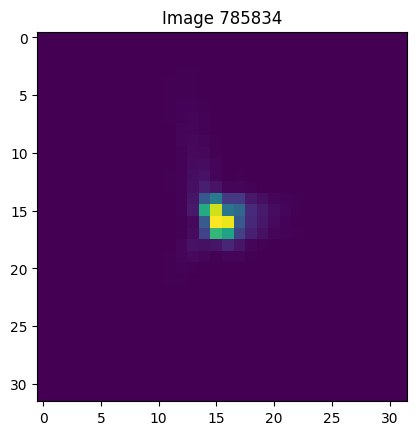

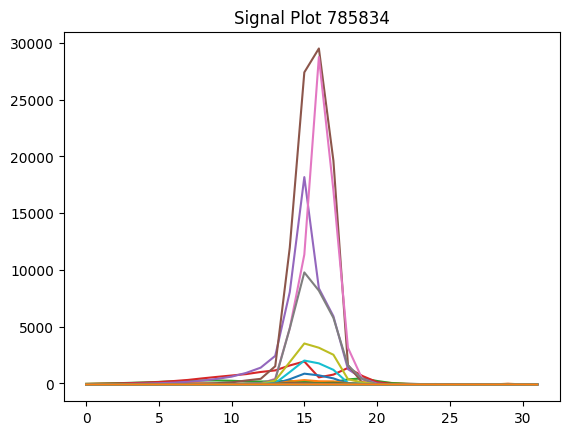

14485303
[[-90.31983118 -90.85973118 -88.84090577 ... -90.16065254 -92.24592846
  -91.03717132]
 [-91.17033262 -87.86414534 -91.23735227 ... -91.38727812 -90.92678865
  -90.4551568 ]
 [-89.21583014 -88.44907049 -88.72348117 ... -87.96676321 -89.19300958
  -91.29892947]
 ...
 [-86.59508876 -88.36890196 -87.76385621 ... -91.72453942 -90.40393043
  -88.34459526]
 [-81.88813344 -89.61821255 -88.21568975 ... -91.02257946 -90.96763762
  -89.89631923]
 [-90.28448998 -89.20175566 -89.00765737 ... -70.53960757 -87.85773857
  -91.1936641 ]]


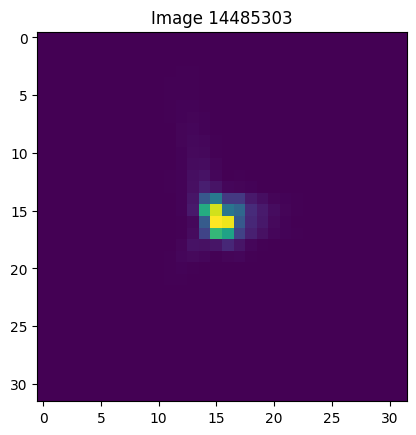

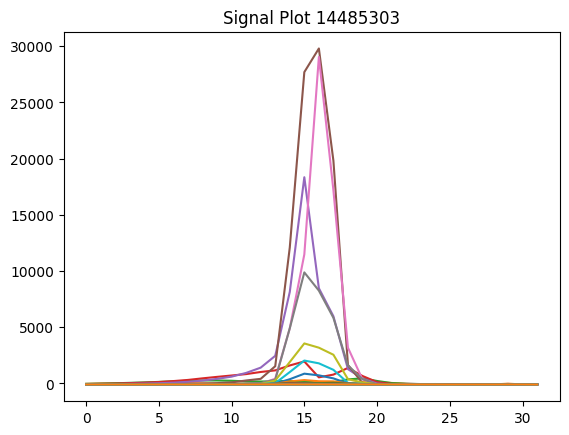

17002355
[[49.33563168 48.83837452 48.95019229 ... 47.71745492 48.85275248
  49.09034442]
 [48.9053421  52.26286071 49.49736325 ... 49.1845808  48.33192074
  48.26715572]
 [49.71840799 50.42182934 49.11972977 ... 51.44135438 49.14284224
  48.09555213]
 ...
 [53.17329306 50.74268893 51.88470162 ... 48.49655318 49.66758707
  50.21423415]
 [57.88557089 50.4505926  52.39036473 ... 48.78261494 49.47989965
  48.4862507 ]
 [49.14063237 49.83193936 51.1273319  ... 67.63855723 51.17884329
  48.80013738]]


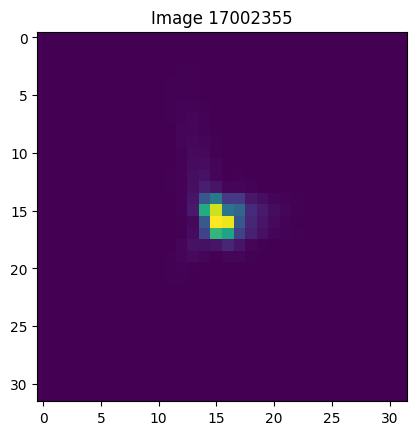

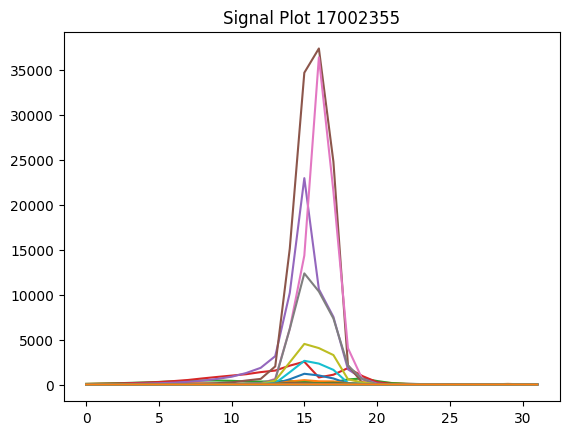

24135240
[[-84.1676364  -84.66745366 -82.79554322 ... -84.08876288 -85.96303388
  -84.94983279]
 [-85.02121995 -81.6648899  -85.11879144 ... -85.1548501  -84.82531147
  -84.33788084]
 [-83.16605584 -82.34261533 -82.63714223 ... -81.84178787 -83.10186644
  -85.12637412]
 ...
 [-80.49644233 -82.31425111 -81.65550007 ... -85.55304022 -84.23378497
  -82.23931418]
 [-75.8412305  -83.4428204  -82.00770761 ... -84.83871575 -84.8667732
  -83.7778554 ]
 [-84.23828062 -83.0397192  -82.82634273 ... -64.4665748  -81.7499046
  -84.99893925]]


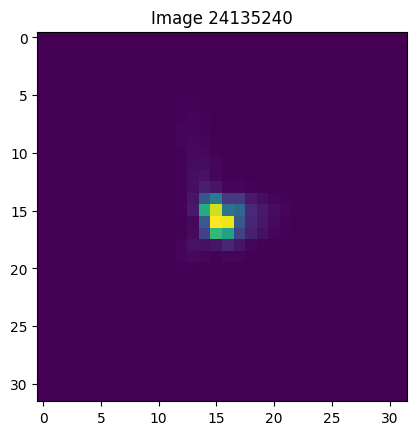

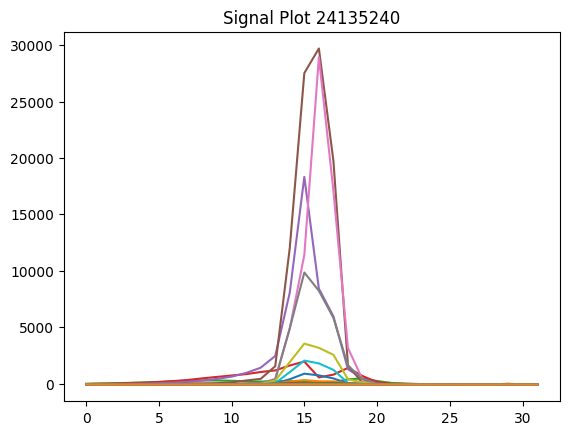

25070640
[[46.44322085 45.92875396 46.13119101 ... 44.81838412 45.99534921
  46.12566609]
 [45.95464177 49.36721028 46.47629113 ... 46.18740352 45.46602277
  45.41312014]
 [46.8621478  47.44376071 46.10350535 ... 48.48244918 46.23582938
  45.25590069]
 ...
 [50.3600375  47.80266478 48.98132422 ... 45.56983919 46.75658613
  47.37881467]
 [54.87895405 47.61241288 49.34915867 ... 45.7995672  46.49392427
  45.62592003]
 [46.18088452 47.00359321 48.08590835 ... 64.6784145  48.29607809
  45.82870605]]


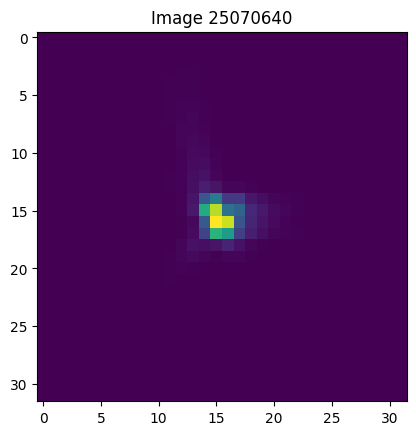

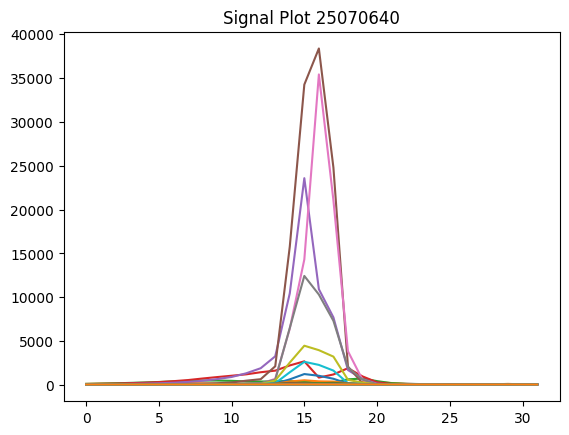

26372015


KeyboardInterrupt: 

In [27]:
import pandas,os
import matplotlib.pyplot as plt
import numpy
from PIL import Image
import itertools

def apply_linear_corr(linear_corr,clean_signal):
    linear_corr = numpy.flip(linear_corr, axis=0)
    for x, y in itertools.product(
                range(clean_signal.shape[1]), range(clean_signal.shape[2])
            ):
        poli = numpy.poly1d(linear_corr[:, x, y])
        clean_signal[:, x, y] = poli(clean_signal[:, x, y])
    return clean_signal

train_adc=pandas.read_csv("/kaggle/input/ariel-data-challenge-2024/train_adc_info.csv")
if os.path.exists(f"/kaggle/working/train_rafire")==False:
    os.mkdir(f"/kaggle/working/train_rafire")
    
for i in train_adc['planet_id']:
    if os.path.exists(f"/kaggle/working/train_rafire/{i}")==False:
        os.mkdir(f"/kaggle/working/train_rafire/{i}")
    print(i)
    rafire_exo=pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/FGS1_signal.parquet',engine='pyarrow')
    rafire_data=(numpy.array(rafire_exo).reshape(135000, 32, 32)*float(train_adc[train_adc['planet_id']==i]['FGS1_adc_gain']))+float(train_adc[train_adc['planet_id']==i]['FGS1_adc_offset'])

    dark_frame = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/FGS1_calibration/dark.parquet', engine='pyarrow').to_numpy()
    dead_frame = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/FGS1_calibration/dead.parquet', engine='pyarrow').to_numpy()
    flat_frame = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/FGS1_calibration/flat.parquet', engine='pyarrow').to_numpy()
    linear_corr = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/FGS1_calibration/linear_corr.parquet').values.astype(numpy.float64).reshape((6, 32, 32))
    read = pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/train/{i}/FGS1_calibration/read.parquet').values.astype(numpy.float64)

    #print(numpy.array(rafire_exo).reshape(135000, 32, 32))
    
    rafire_z=numpy.add(numpy.add(numpy.subtract(numpy.subtract(rafire_data,dark_frame),dead_frame),flat_frame),read)
    rafire_z=numpy.average(apply_linear_corr(linear_corr,rafire_z),(0))
    numpy.save(f'/kaggle/working/train_rafire/{i}/FGS1_signal.npy',rafire_z)
    print(rafire_z)
    plt.imshow(rafire_z)
    plt.title(f'Image {i}')
    plt.show()
    plt.linear(rafire_z)
    plt.title(f'Signal Plot {i}')
    plt.show()
    
#rafire_exo=pandas.read_parquet(f'/kaggle/input/ariel-data-challenge-2024/axis_info.parquet',engine='pyarrow')
#print(rafire_exo)